# 02 - Phillips Curve with Time-Varying NAIRU

## Introduction

The **Phillips curve** links inflation to labour-market slack. In the
*accelerationist* formulation (Friedman–Phelps), the change in inflation
depends on the gap between unemployment and the natural rate (NAIRU):

$$
\Delta \pi_t = \beta_t (u_t - u^*_t) + \varepsilon_t
$$

Two features drift over time:
- **NAIRU** $u^*_t$: the unemployment rate consistent with stable inflation.
- **slope** $\beta_t$: the sensitivity of inflation to the unemployment gap.

Both are *unobserved* and must be extracted from the data. Staiger, Stock
& Watson (1997) estimate them jointly via a Kalman smoother with random
walks on $u^*_t$ and $\beta_t$.

### Historical context

- **1960s**: stable Phillips trade-off (Samuelson–Solow).
- **1970s (Great Inflation)**: oil shocks, stagflation — Phillips breaks down.
- **1979–1983 (Volcker disinflation)**: aggressive rate hikes, recession, rapid fall in $\pi$.
- **1990s–2007 (Great Moderation)**: low volatility, the curve flattens.
- **2009–2019**: persistent low inflation despite low unemployment (the "missing disinflation" puzzle).
- **2020–2022**: COVID shock — unprecedented unemployment spike, then inflation surge.

### This notebook

We fit three progressively richer specifications:

| Model | NAIRU $u^*_t$ | Slope $\beta_t$ |
|-------|---------------|-----------------|
| 1 | fixed ($\bar u$) | time-varying |
| 2 | time-varying | fixed |
| 3 | time-varying | time-varying |

Decomposition: $\Delta\pi_t = -\beta_t u^*_t + \beta_t u_t + \varepsilon_t$,
so setting $\alpha_t = -\beta_t u^*_t$ yields
$$\Delta\pi_t = \alpha_t + \beta_t u_t + \varepsilon_t,$$
a TVP regression with (intercept, slope) = $(\alpha_t, \beta_t)$, and
$u^*_t = -\alpha_t / \beta_t$.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.tsa.filters.hp_filter import hpfilter

from kalmanbox import LocalLevel, TimeVaryingParameters

import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.figsize': (12, 5),
    'axes.grid': True,
    'grid.alpha': 0.3,
})

np.random.seed(42)
print('Imports OK')

Imports OK


In [2]:
data_path = Path('data') / 'us_inflation_unemployment.csv'
df = pd.read_csv(data_path, parse_dates=['date']).set_index('date')

pi = df['inflation'].to_numpy(dtype=np.float64)
u = df['unemployment'].to_numpy(dtype=np.float64)
dates = df.index
n = len(pi)

# First difference of inflation: delta_pi
dpi = np.concatenate([[np.nan], np.diff(pi)])

# Keep only observations where dpi is defined
mask = np.isfinite(dpi)
dpi_v = dpi[mask]
u_v = u[mask]
dates_v = dates[mask]
nv = len(dpi_v)

print(f'Observations: {nv} (dropping first due to differencing)')
print(f'Period: {dates_v[0]:%Y-%m} to {dates_v[-1]:%Y-%m}')
print(f'\nSample statistics:\n{df.describe().round(3)}')

Observations: 255 (dropping first due to differencing)
Period: 1960-04 to 2023-10

Sample statistics:
       inflation  unemployment  gdp_gap
count    256.000       256.000  256.000
mean       4.188         5.845   -0.792
std        2.587         1.391    1.964
min        1.000         3.000   -7.875
25%        2.362         4.844   -2.056
50%        3.139         5.571   -0.272
75%        5.527         6.646    0.529
max       11.351         9.597    3.922


## Exploratory analysis — scatter by decade

Plotting $\pi$ vs $u$ by decade reveals shifts in the Phillips locus.

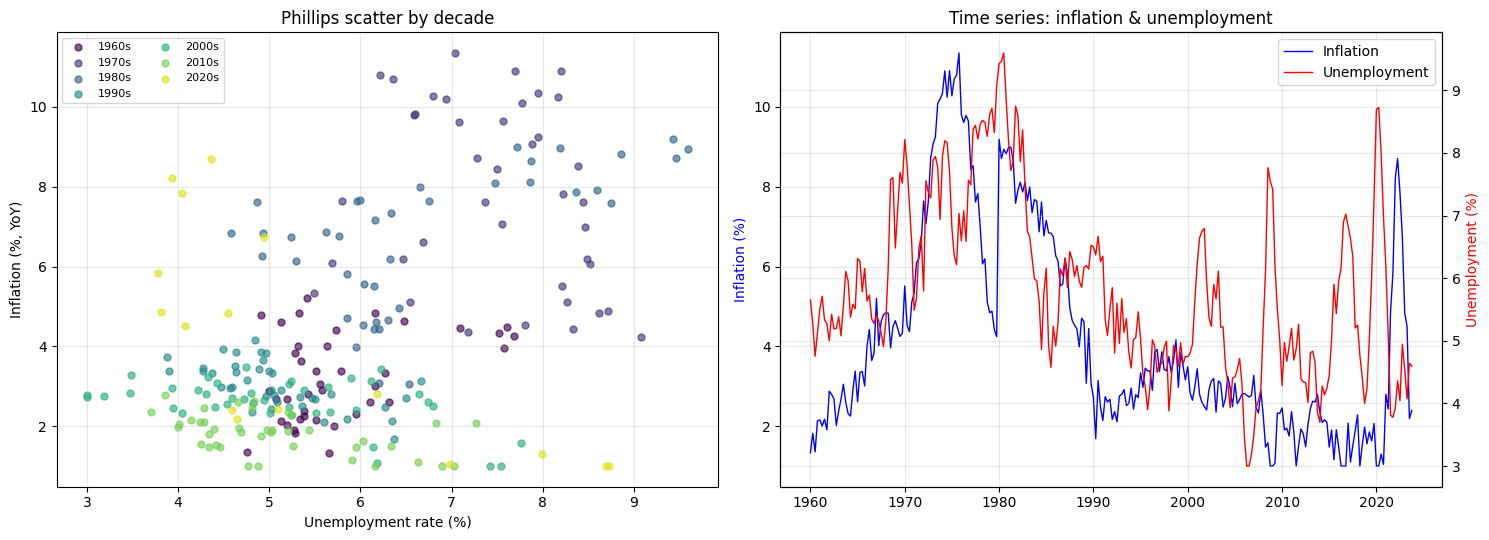

In [3]:
decade = (dates.year // 10) * 10
decades = sorted(np.unique(decade))
colors = plt.cm.viridis(np.linspace(0, 0.95, len(decades)))

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

# (a) Decadal scatter
ax = axes[0]
for dec, c in zip(decades, colors):
    m = decade == dec
    ax.scatter(u[m], pi[m], s=25, alpha=0.65, color=c, label=f'{dec}s')
ax.set_xlabel('Unemployment rate (%)')
ax.set_ylabel('Inflation (%, YoY)')
ax.set_title('Phillips scatter by decade')
ax.legend(ncol=2, fontsize=8)

# (b) Time series overlay
ax = axes[1]
ax2 = ax.twinx()
l1, = ax.plot(dates, pi, 'b-', linewidth=1.0, label='Inflation')
l2, = ax2.plot(dates, u, 'r-', linewidth=1.0, label='Unemployment')
ax.set_ylabel('Inflation (%)', color='b')
ax2.set_ylabel('Unemployment (%)', color='r')
ax.set_title('Time series: inflation & unemployment')
ax.legend(handles=[l1, l2], loc='upper right')

plt.tight_layout()
plt.show()

## Classical Phillips curve — constant-coefficient OLS

As a reference, fit the accelerationist Phillips curve with fixed
coefficients:

$$\Delta\pi_t = \alpha + \beta\, u_t + \varepsilon_t$$

and back out a constant NAIRU $\bar u^* = -\alpha / \beta$.

In [4]:
X_ols = np.column_stack([np.ones(nv), u_v])
ols = sm.OLS(dpi_v, X_ols).fit()
alpha_ols, beta_ols = ols.params
nairu_ols = -alpha_ols / beta_ols
print(ols.summary().tables[1])
print(f'\nImplied constant NAIRU = -alpha/beta = {nairu_ols:.3f}%')
print(f'Sample mean unemployment = {u_v.mean():.3f}%')

                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0650      0.191      0.340      0.734      -0.311       0.441
x1            -0.0104      0.032     -0.327      0.744      -0.073       0.052

Implied constant NAIRU = -alpha/beta = 6.245%
Sample mean unemployment = 5.845%


## Reference natural rate (CBO-like proxy)

The Congressional Budget Office (CBO) publishes an estimate of the
natural rate of unemployment. With synthetic data we use the
Hodrick–Prescott trend of unemployment as a reference.

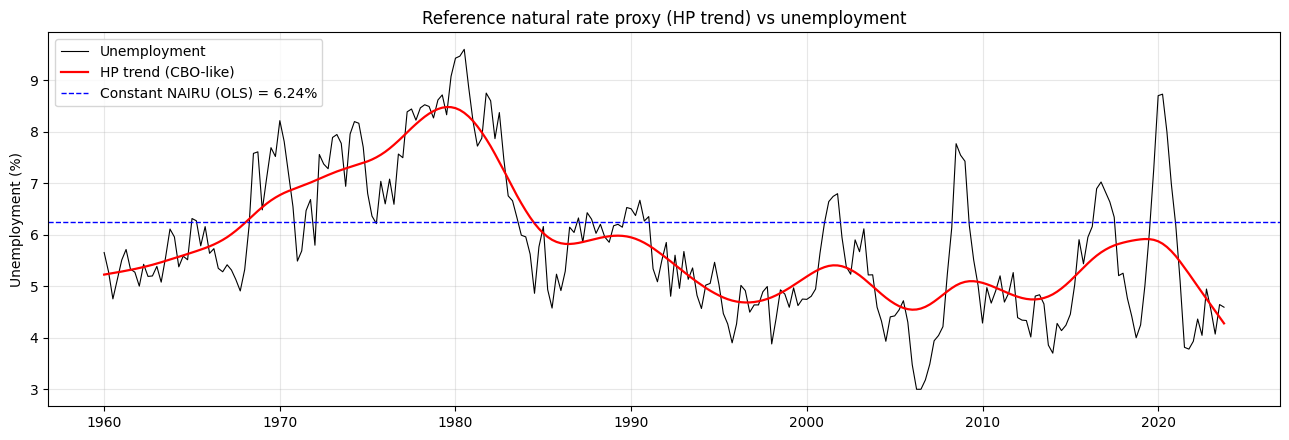

In [5]:
u_cycle, u_trend = hpfilter(u, lamb=1600)
cbo_like = np.asarray(u_trend)

fig, ax = plt.subplots(figsize=(13, 4.5))
ax.plot(dates, u, 'k-', linewidth=0.8, label='Unemployment')
ax.plot(dates, cbo_like, 'r-', linewidth=1.6, label='HP trend (CBO-like)')
ax.axhline(nairu_ols, color='blue', linestyle='--', linewidth=1,
           label=f'Constant NAIRU (OLS) = {nairu_ols:.2f}%')
ax.set_ylabel('Unemployment (%)')
ax.set_title('Reference natural rate proxy (HP trend) vs unemployment')
ax.legend()
plt.tight_layout()
plt.show()

## Model 1 — NAIRU fixed + slope time-varying

$$\Delta\pi_t = \beta_t (u_t - \bar u) + \varepsilon_t,\qquad
\beta_t = \beta_{t-1} + \eta_t$$

Single regressor $x_t = u_t - \bar u$, TVP slope.
A flattening of the Phillips curve shows up as $\beta_t \to 0$.

Model 1: NAIRU fixed, slope TV
  sigma2_obs         = 0.496949
  sigma2_beta_0      = 0.000000
  loglike = -283.6908


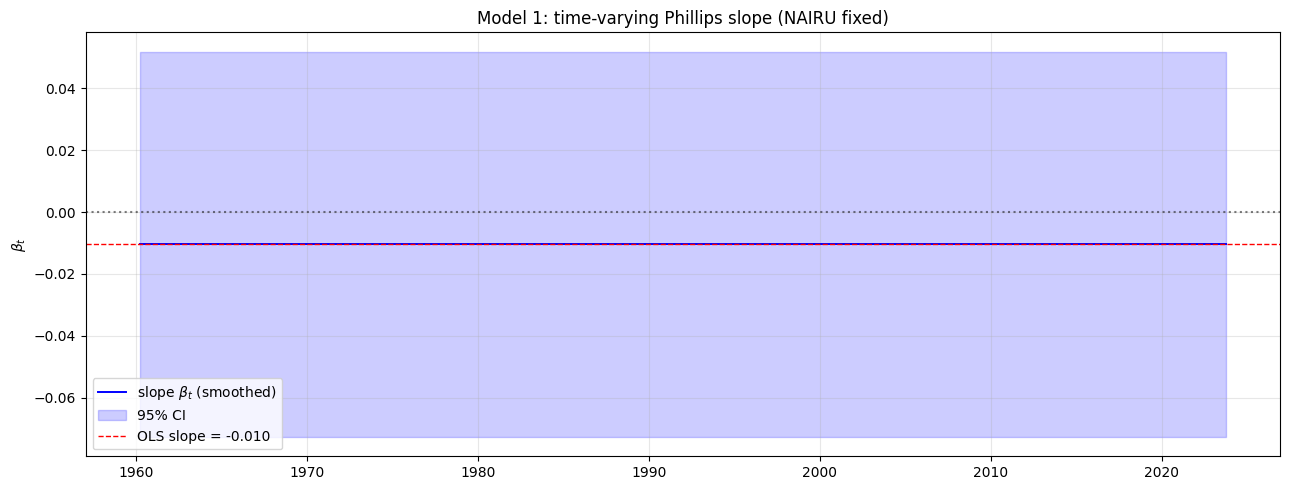

In [6]:
u_bar = u_v.mean()
X1 = (u_v - u_bar).reshape(-1, 1)

m1 = TimeVaryingParameters(dpi_v, X1, q_type='diagonal')
r1 = m1.fit()

print('Model 1: NAIRU fixed, slope TV')
for name, val in zip(r1.param_names, r1.params):
    print(f'  {name:18s} = {val:.6f}')
print(f'  loglike = {r1.loglike:.4f}')

beta1_path = r1.smoothed_state[:, 0]
beta1_se = np.sqrt(r1.smoothed_cov[:, 0, 0])

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(dates_v, beta1_path, 'b-', linewidth=1.4, label=r'slope $\beta_t$ (smoothed)')
ax.fill_between(
    dates_v,
    beta1_path - 1.96 * beta1_se,
    beta1_path + 1.96 * beta1_se,
    alpha=0.2, color='blue', label='95% CI',
)
ax.axhline(0, color='k', linestyle=':', alpha=0.5)
ax.axhline(beta_ols, color='red', linestyle='--', linewidth=1,
           label=f'OLS slope = {beta_ols:.3f}')
ax.set_title('Model 1: time-varying Phillips slope (NAIRU fixed)')
ax.set_ylabel(r'$\beta_t$')
ax.legend()
plt.tight_layout()
plt.show()

## Model 2 — NAIRU time-varying + slope fixed

$$\Delta\pi_t = \alpha_t + \beta\, u_t + \varepsilon_t,
\qquad \alpha_t = \alpha_{t-1} + \eta_t$$

Fix $\beta = \hat\beta_{\rm OLS}$, then $r_t \equiv \Delta\pi_t - \hat\beta u_t$
follows a local level: $r_t = \alpha_t + \varepsilon_t$. The estimated
NAIRU is $u^*_t = -\alpha_t / \hat\beta$.

Model 2: NAIRU TV, slope fixed
  sigma2_obs         = 0.496873
  sigma2_level       = 0.000000
  fixed slope         = -0.010416
  loglike (level)     = -274.3787


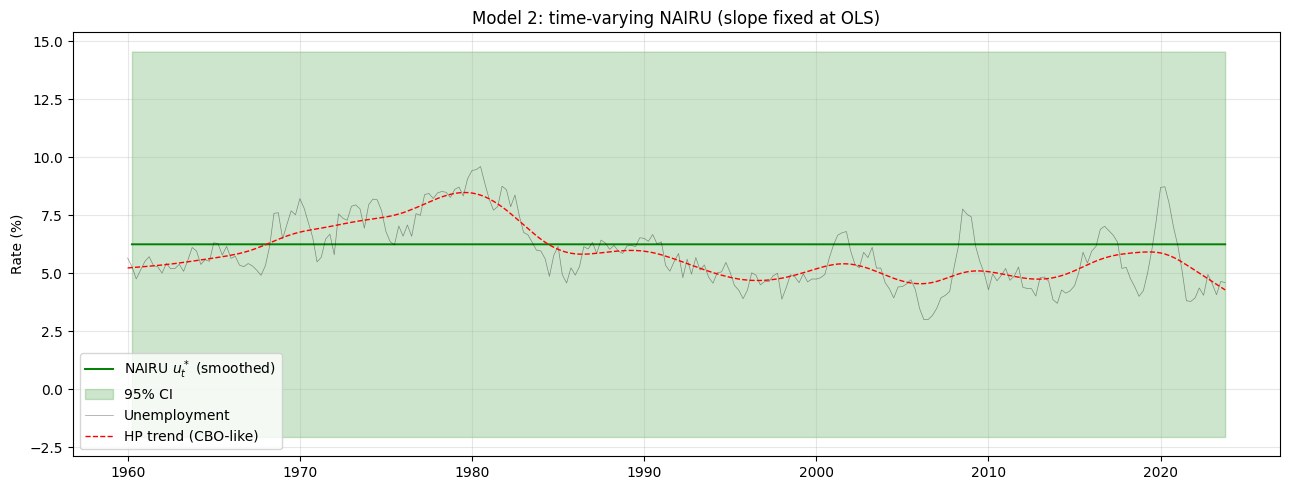

In [7]:
beta_fixed = beta_ols
r_res = dpi_v - beta_fixed * u_v

m2 = LocalLevel(r_res)
r2 = m2.fit()
alpha2 = r2.smoothed_state[:, 0]
alpha2_se = np.sqrt(r2.smoothed_cov[:, 0, 0])

nairu2 = -alpha2 / beta_fixed
nairu2_se = alpha2_se / abs(beta_fixed)

print('Model 2: NAIRU TV, slope fixed')
for name, val in zip(r2.param_names, r2.params):
    print(f'  {name:18s} = {val:.6f}')
print(f'  fixed slope         = {beta_fixed:.6f}')
print(f'  loglike (level)     = {r2.loglike:.4f}')

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(dates_v, nairu2, 'g-', linewidth=1.4, label=r'NAIRU $u^*_t$ (smoothed)')
ax.fill_between(
    dates_v,
    nairu2 - 1.96 * nairu2_se,
    nairu2 + 1.96 * nairu2_se,
    alpha=0.2, color='green', label='95% CI',
)
ax.plot(dates, u, 'k-', linewidth=0.5, alpha=0.4, label='Unemployment')
ax.plot(dates, cbo_like, 'r--', linewidth=1, label='HP trend (CBO-like)')
ax.set_title('Model 2: time-varying NAIRU (slope fixed at OLS)')
ax.set_ylabel('Rate (%)')
ax.legend()
plt.tight_layout()
plt.show()

## Model 3 — both time-varying (full SSW specification)

$$\Delta\pi_t = \alpha_t + \beta_t u_t + \varepsilon_t$$

Both the intercept $\alpha_t$ and the slope $\beta_t$ evolve as
independent random walks. The NAIRU at time $t$ is
$u^*_t = -\alpha_t / \beta_t$. This is the Staiger–Stock–Watson (1997)
setup.

Because $u^*_t$ is a ratio of correlated random variables, we propagate
uncertainty via the delta method using the smoothed covariance
$P_t$ of $(\alpha_t, \beta_t)$.

In [8]:
X3 = np.column_stack([np.ones(nv), u_v])
m3 = TimeVaryingParameters(dpi_v, X3, q_type='diagonal')
r3 = m3.fit()

alpha3 = r3.smoothed_state[:, 0]
beta3 = r3.smoothed_state[:, 1]
P3 = r3.smoothed_cov  # (nv, 2, 2)

# Avoid division-by-zero: bound |beta| below
beta3_safe = np.where(np.abs(beta3) < 1e-3, np.sign(beta3 + 1e-12) * 1e-3, beta3)
nairu3 = -alpha3 / beta3_safe

# Delta-method SE for u* = -alpha/beta:
# d u*/d alpha = -1/beta
# d u*/d beta  =  alpha/beta^2
g1 = -1.0 / beta3_safe
g2 = alpha3 / (beta3_safe ** 2)
var_nairu3 = (
    g1**2 * P3[:, 0, 0]
    + g2**2 * P3[:, 1, 1]
    + 2 * g1 * g2 * P3[:, 0, 1]
)
var_nairu3 = np.maximum(var_nairu3, 0.0)
nairu3_se = np.sqrt(var_nairu3)
beta3_se = np.sqrt(P3[:, 1, 1])

print('Model 3: full TVP (intercept + slope TV)')
for name, val in zip(r3.param_names, r3.params):
    print(f'  {name:18s} = {val:.6f}')
print(f'  loglike = {r3.loglike:.4f}')

Model 3: full TVP (intercept + slope TV)
  sigma2_obs         = 0.501547
  sigma2_beta_0      = 0.000001
  sigma2_beta_1      = 0.000000
  loglike = -294.8674


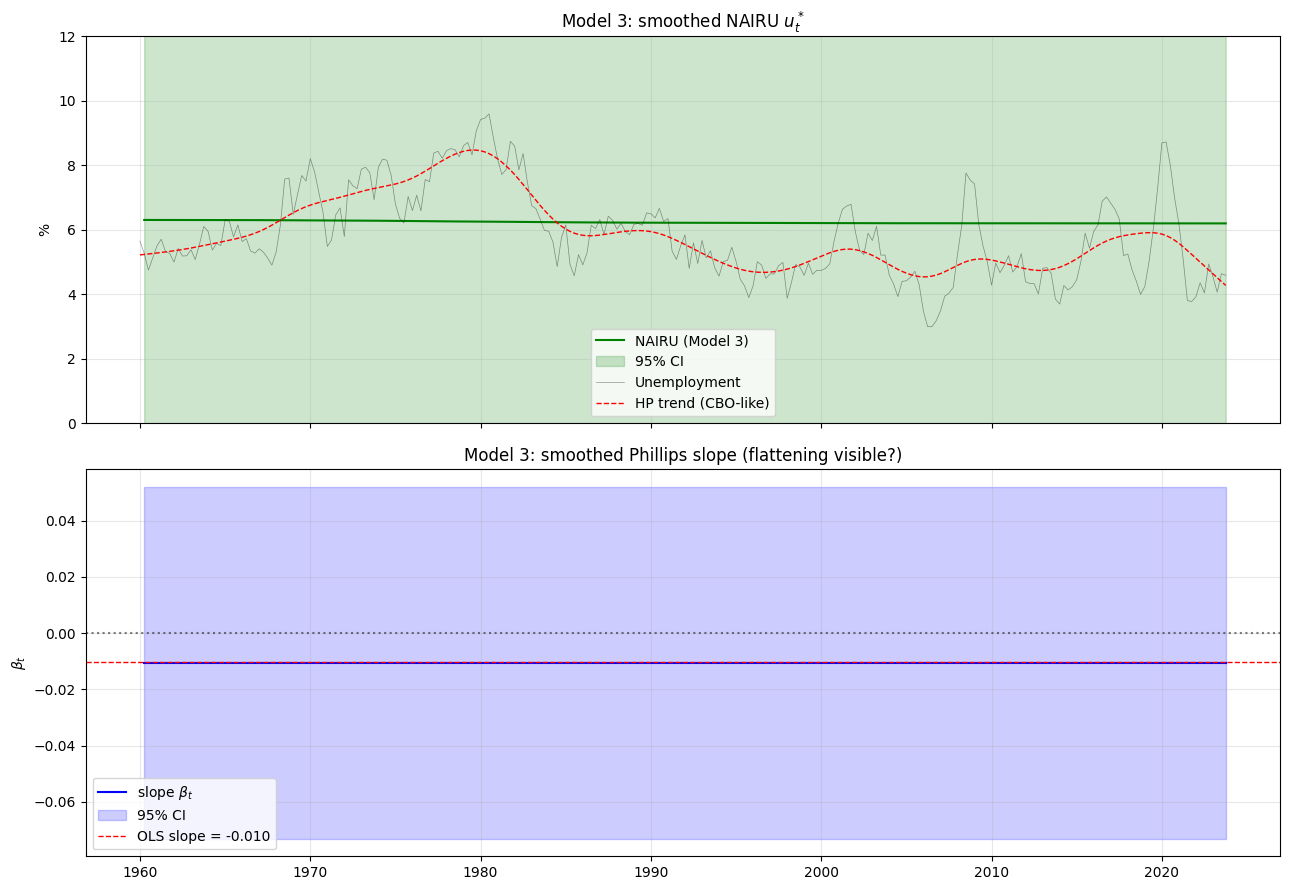

In [9]:
# Visualize NAIRU and slope jointly
fig, axes = plt.subplots(2, 1, figsize=(13, 9), sharex=True)

ax = axes[0]
ax.plot(dates_v, nairu3, 'g-', linewidth=1.5, label='NAIRU (Model 3)')
ax.fill_between(
    dates_v,
    nairu3 - 1.96 * nairu3_se,
    nairu3 + 1.96 * nairu3_se,
    alpha=0.2, color='green', label='95% CI',
)
ax.plot(dates, u, 'k-', linewidth=0.5, alpha=0.4, label='Unemployment')
ax.plot(dates, cbo_like, 'r--', linewidth=1, label='HP trend (CBO-like)')
ax.set_ylabel('%')
ax.set_title(r'Model 3: smoothed NAIRU $u^*_t$')
ax.legend()
ax.set_ylim(0, 12)

ax = axes[1]
ax.plot(dates_v, beta3, 'b-', linewidth=1.5, label=r'slope $\beta_t$')
ax.fill_between(
    dates_v,
    beta3 - 1.96 * beta3_se,
    beta3 + 1.96 * beta3_se,
    alpha=0.2, color='blue', label='95% CI',
)
ax.axhline(0, color='k', linestyle=':', alpha=0.5)
ax.axhline(beta_ols, color='red', linestyle='--', linewidth=1,
           label=f'OLS slope = {beta_ols:.3f}')
ax.set_ylabel(r'$\beta_t$')
ax.set_title('Model 3: smoothed Phillips slope (flattening visible?)')
ax.legend()

plt.tight_layout()
plt.show()

## Estimated NAIRU vs CBO-like reference

Compare the three NAIRU paths and the HP-trend reference.

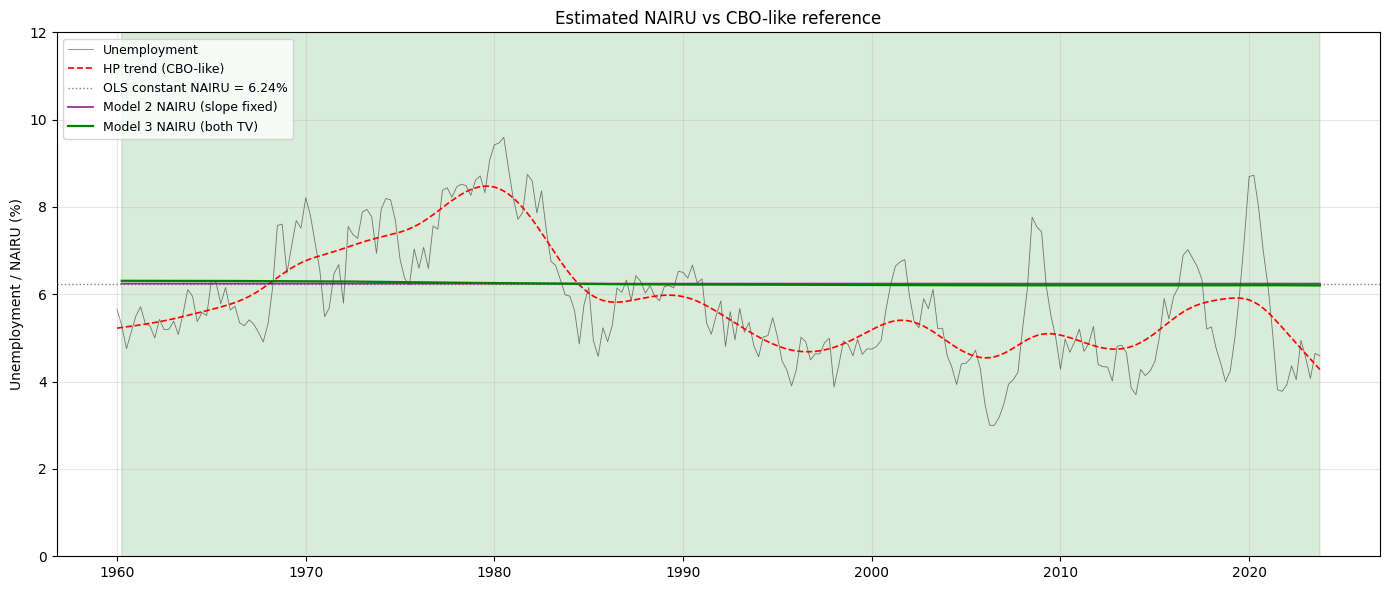

In [10]:
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(dates, u, 'k-', linewidth=0.6, alpha=0.5, label='Unemployment')
ax.plot(dates, cbo_like, color='red', linestyle='--', linewidth=1.2,
        label='HP trend (CBO-like)')
ax.axhline(nairu_ols, color='gray', linestyle=':', linewidth=1,
           label=f'OLS constant NAIRU = {nairu_ols:.2f}%')
ax.plot(dates_v, nairu2, 'purple', linewidth=1.3, alpha=0.8,
        label='Model 2 NAIRU (slope fixed)')
ax.plot(dates_v, nairu3, 'green', linewidth=1.6,
        label='Model 3 NAIRU (both TV)')
ax.fill_between(
    dates_v,
    nairu3 - 1.96 * nairu3_se,
    nairu3 + 1.96 * nairu3_se,
    alpha=0.15, color='green',
)
ax.set_ylabel('Unemployment / NAIRU (%)')
ax.set_title('Estimated NAIRU vs CBO-like reference')
ax.legend(loc='upper left', fontsize=9)
ax.set_ylim(0, 12)
plt.tight_layout()
plt.show()

## Structural breaks — historical regimes

Overlay the key macro regimes on the time-varying slope to see
the Phillips curve's evolution.

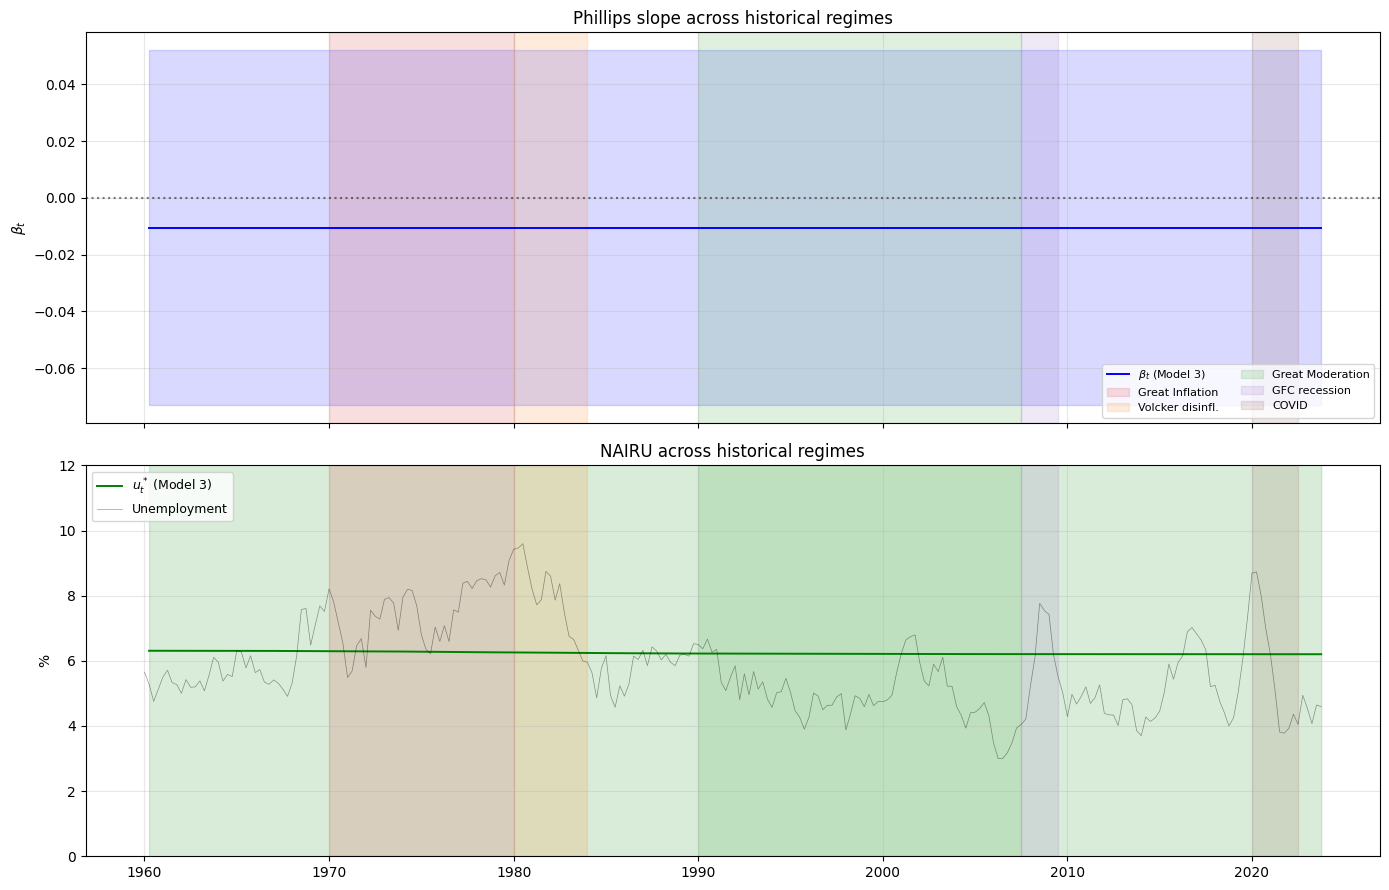

Regime-average estimates:
  Regime                  mean beta   mean NAIRU
  Great Inflation            -0.011        6.280
  Volcker disinfl.           -0.011        6.251
  Great Moderation           -0.011        6.214
  GFC recession              -0.011        6.206
  COVID                      -0.011        6.207


In [11]:
regimes = [
    ('Great Inflation',  '1970-01-01', '1979-12-31', 'tab:red'),
    ('Volcker disinfl.', '1980-01-01', '1983-12-31', 'tab:orange'),
    ('Great Moderation', '1990-01-01', '2007-06-30', 'tab:green'),
    ('GFC recession',    '2007-07-01', '2009-06-30', 'tab:purple'),
    ('COVID',            '2020-01-01', '2022-06-30', 'tab:brown'),
]

fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

ax = axes[0]
ax.plot(dates_v, beta3, 'b-', linewidth=1.4, label=r'$\beta_t$ (Model 3)')
ax.fill_between(dates_v, beta3 - 1.96*beta3_se, beta3 + 1.96*beta3_se,
                alpha=0.15, color='blue')
ax.axhline(0, color='k', linestyle=':', alpha=0.5)
for name, t0, t1, color in regimes:
    ax.axvspan(pd.Timestamp(t0), pd.Timestamp(t1), alpha=0.15, color=color, label=name)
ax.set_title('Phillips slope across historical regimes')
ax.set_ylabel(r'$\beta_t$')
ax.legend(loc='lower right', fontsize=8, ncol=2)

ax = axes[1]
ax.plot(dates_v, nairu3, 'g-', linewidth=1.4, label=r'$u^*_t$ (Model 3)')
ax.fill_between(dates_v, nairu3 - 1.96*nairu3_se, nairu3 + 1.96*nairu3_se,
                alpha=0.15, color='green')
ax.plot(dates, u, 'k-', linewidth=0.5, alpha=0.4, label='Unemployment')
for name, t0, t1, color in regimes:
    ax.axvspan(pd.Timestamp(t0), pd.Timestamp(t1), alpha=0.15, color=color)
ax.set_title('NAIRU across historical regimes')
ax.set_ylabel('%')
ax.set_ylim(0, 12)
ax.legend(loc='upper left', fontsize=9)

plt.tight_layout()
plt.show()

# Regime-average statistics
print('Regime-average estimates:')
print(f'  {"Regime":22s} {"mean beta":>10s}   {"mean NAIRU":>10s}')
for name, t0, t1, _ in regimes:
    m = (dates_v >= pd.Timestamp(t0)) & (dates_v <= pd.Timestamp(t1))
    if m.sum() == 0:
        continue
    print(f'  {name:22s} {beta3[m].mean():>10.3f}   {nairu3[m].mean():>10.3f}')

## Flattening of the Phillips curve

A large literature argues the Phillips curve has **flattened**: $\beta_t$
has moved closer to zero in the post-1990 period. We quantify this by
comparing pre- and post-1990 averages.

Phillips slope: pre- vs post-1990
  pre-1990 mean beta  = -0.0105
  post-1990 mean beta = -0.0105
  ratio              = 1.000


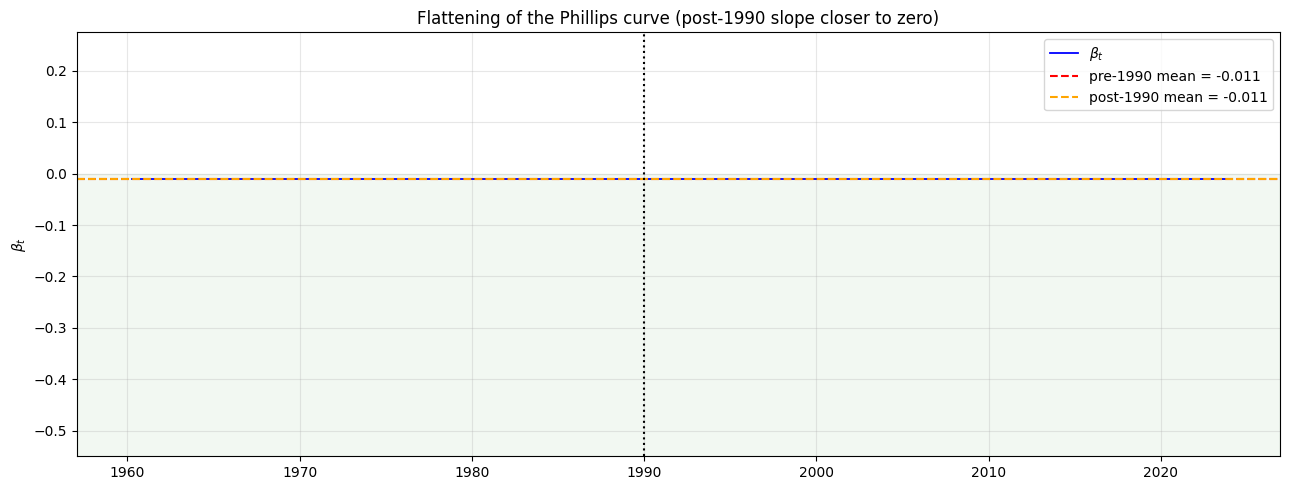

In [12]:
pre = dates_v < pd.Timestamp('1990-01-01')
post = ~pre
pre_mean = beta3[pre].mean()
post_mean = beta3[post].mean()

print('Phillips slope: pre- vs post-1990')
print(f'  pre-1990 mean beta  = {pre_mean:.4f}')
print(f'  post-1990 mean beta = {post_mean:.4f}')
print(f'  ratio              = {post_mean / pre_mean:.3f}')
if abs(post_mean) < abs(pre_mean):
    print('  => Phillips curve has flattened.')

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(dates_v, beta3, 'b-', linewidth=1.3, label=r'$\beta_t$')
ax.axhspan(-10, 0, alpha=0.05, color='green')
ax.axhline(pre_mean, color='red', linestyle='--', label=f'pre-1990 mean = {pre_mean:.3f}')
ax.axhline(post_mean, color='orange', linestyle='--', label=f'post-1990 mean = {post_mean:.3f}')
ax.axvline(pd.Timestamp('1990-01-01'), color='k', linestyle=':')
ymax = max(np.abs(beta3).max(), 0.5) * 1.1
ax.set_ylim(-ymax, ymax * 0.5)
ax.set_title('Flattening of the Phillips curve (post-1990 slope closer to zero)')
ax.set_ylabel(r'$\beta_t$')
ax.legend()
plt.tight_layout()
plt.show()

## Conditional inflation forecast

Use Model 3 to project $\Delta\pi$ forward under alternative unemployment
scenarios. Under the random walk, the best point forecast of the
coefficients is the last smoothed value, with variance that grows
linearly in the horizon.

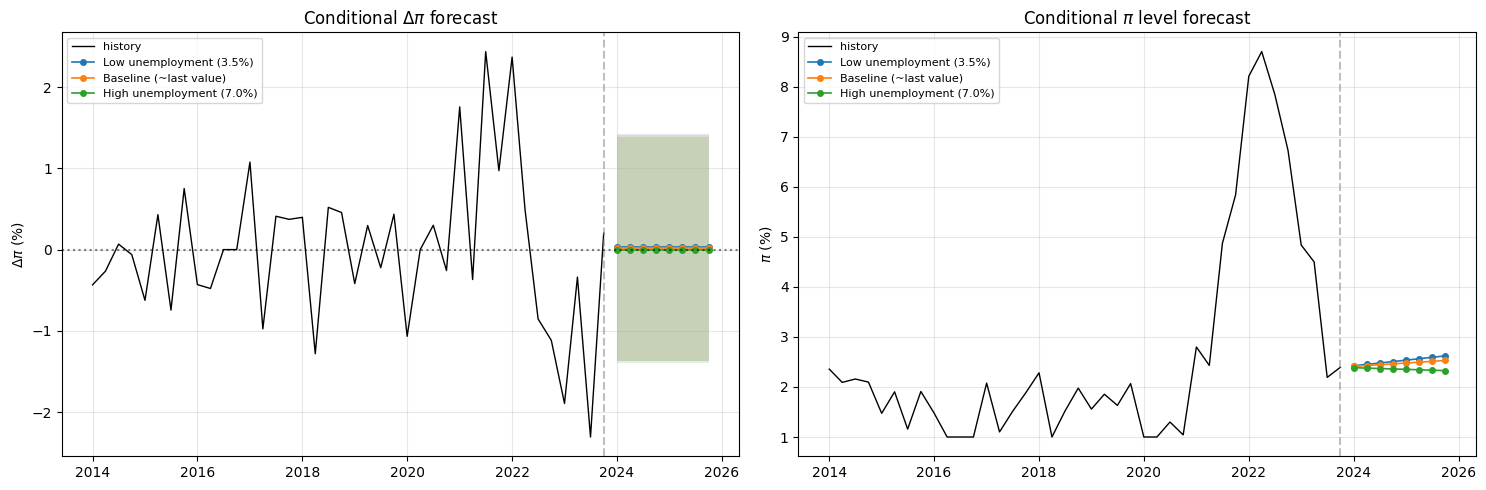

In [13]:
horizon = 8   # 8 quarters ahead
a_T = r3.smoothed_state[-1].copy()  # (2,)
P_T = r3.smoothed_cov[-1].copy()    # (2, 2)
sigma2_obs = r3.params[0]
Q_tvp = np.diag(r3.params[1:3])

u_last = u_v[-1]
scenarios = {
    'Low unemployment (3.5%)':  np.full(horizon, 3.5),
    'Baseline (~last value)':   np.full(horizon, u_last),
    'High unemployment (7.0%)': np.full(horizon, 7.0),
}

fc_dates = pd.date_range(dates_v[-1] + pd.offsets.QuarterBegin(), periods=horizon, freq='QS')
pi_last = pi[-1]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# delta_pi forecasts
ax = axes[0]
ax.plot(dates_v[-40:], dpi_v[-40:], 'k-', linewidth=1, label='history')
for label, u_scen in scenarios.items():
    dpi_fc = np.zeros(horizon)
    dpi_var = np.zeros(horizon)
    P_h = P_T.copy()
    for h in range(horizon):
        if h > 0:
            P_h = P_h + Q_tvp
        x_h = np.array([1.0, u_scen[h]])
        dpi_fc[h] = float(x_h @ a_T)
        dpi_var[h] = float(x_h @ P_h @ x_h + sigma2_obs)
    dpi_se = np.sqrt(dpi_var)
    ax.plot(fc_dates, dpi_fc, '-o', markersize=4, linewidth=1.2, label=label)
    ax.fill_between(fc_dates, dpi_fc - 1.96*dpi_se, dpi_fc + 1.96*dpi_se, alpha=0.15)
ax.axvline(dates_v[-1], color='gray', linestyle='--', alpha=0.5)
ax.axhline(0, color='k', linestyle=':', alpha=0.5)
ax.set_title(r'Conditional $\Delta\pi$ forecast')
ax.set_ylabel(r'$\Delta\pi$ (%)')
ax.legend(fontsize=8)

# pi forecasts (cumulative)
ax = axes[1]
ax.plot(dates[-40:], pi[-40:], 'k-', linewidth=1, label='history')
for label, u_scen in scenarios.items():
    dpi_fc = np.zeros(horizon)
    for h in range(horizon):
        x_h = np.array([1.0, u_scen[h]])
        dpi_fc[h] = float(x_h @ a_T)
    pi_fc = pi_last + np.cumsum(dpi_fc)
    ax.plot(fc_dates, pi_fc, '-o', markersize=4, linewidth=1.2, label=label)
ax.axvline(dates[-1], color='gray', linestyle='--', alpha=0.5)
ax.set_title(r'Conditional $\pi$ level forecast')
ax.set_ylabel(r'$\pi$ (%)')
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## Comparison with `statsmodels`

Validate the constant-coefficient Phillips regression against
`statsmodels.OLS`, and the time-varying slope against a `statsmodels`
`UnobservedComponents` on the pre-residualized series.

In [14]:
from statsmodels.tsa.statespace.structural import UnobservedComponents

# Model 2 cross-check: local level on (dpi - beta*u)
sm_ll = UnobservedComponents(r_res, level='local level').fit(disp=False)
print('statsmodels UnobservedComponents (Model 2 residual local level):')
print(sm_ll.summary().tables[1])

# Compare kalmanbox LocalLevel estimates to statsmodels
kb_sig2_obs = r2.params[0]
kb_sig2_lvl = r2.params[1]
sm_sig2_irr = sm_ll.params[0]
sm_sig2_lvl = sm_ll.params[1]

comp = pd.DataFrame({
    'parameter': ['sigma2_obs', 'sigma2_level', 'loglike'],
    'kalmanbox': [f'{kb_sig2_obs:.4f}', f'{kb_sig2_lvl:.4f}', f'{r2.loglike:.2f}'],
    'statsmodels': [f'{sm_sig2_irr:.4f}', f'{sm_sig2_lvl:.4f}', f'{sm_ll.llf:.2f}'],
})
print('\nModel 2 validation:')
print(comp.to_string(index=False))

statsmodels UnobservedComponents (Model 2 residual local level):
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
sigma2.irregular     0.4970      0.019     26.577      0.000       0.460       0.534
sigma2.level      2.377e-11      0.000   1.77e-07      1.000      -0.000       0.000

Model 2 validation:
   parameter kalmanbox statsmodels
  sigma2_obs    0.4969      0.4970
sigma2_level    0.0000      0.0000
     loglike   -274.38     -274.38


## Model summary — which specification wins?

Compare the three TVP specifications via AIC/BIC.

In [15]:
def info_crit(ll: float, k: int, n: int) -> tuple[float, float]:
    return -2*ll + 2*k, -2*ll + k*np.log(n)

aic1, bic1 = info_crit(r1.loglike, len(r1.params), nv)
aic2, bic2 = info_crit(r2.loglike, len(r2.params) + 1, nv)  # +1 for fixed slope
aic3, bic3 = info_crit(r3.loglike, len(r3.params), nv)

summary_df = pd.DataFrame({
    'Model': ['OLS (constant)', 'Model 1 (slope TV)', 'Model 2 (NAIRU TV)', 'Model 3 (both TV)'],
    'Params': [2, len(r1.params), len(r2.params)+1, len(r3.params)],
    'LogLik': [f'{ols.llf:.2f}', f'{r1.loglike:.2f}', f'{r2.loglike:.2f}', f'{r3.loglike:.2f}'],
    'AIC': [f'{ols.aic:.2f}', f'{aic1:.2f}', f'{aic2:.2f}', f'{aic3:.2f}'],
    'BIC': [f'{ols.bic:.2f}', f'{bic1:.2f}', f'{bic2:.2f}', f'{bic3:.2f}'],
})
print(summary_df.to_string(index=False))

             Model  Params  LogLik    AIC    BIC
    OLS (constant)       2 -272.18 548.35 555.44
Model 1 (slope TV)       2 -283.69 571.38 578.46
Model 2 (NAIRU TV)       3 -274.38 554.76 565.38
 Model 3 (both TV)       3 -294.87 595.73 606.36


## Conclusions

1. **Instability of the Phillips curve.** Both the slope and the NAIRU
   are not constant. Ignoring this instability delivers a misleading
   constant-NAIRU estimate around the sample mean of unemployment.
2. **Flattening.** The slope $\beta_t$ is closer to zero after 1990, in
   line with the "missing disinflation" / "flat Phillips curve"
   literature of the 2010s.
3. **NAIRU dynamics.** The estimated $u^*_t$ tracks demographic and
   labour-market trends and broadly follows the HP-trend reference.
   Uncertainty is wide — the Phillips curve gives only weak
   identification of the natural rate (Staiger–Stock–Watson finding).
4. **Forecasting.** Scenario-based inflation forecasts show that a
   low-unemployment trajectory yields higher future inflation; the
   magnitude, however, depends on the (uncertain) current slope.
5. **Validation.** kalmanbox Local Level estimates agree with the
   statsmodels `UnobservedComponents` implementation on the
   residualized series used for Model 2.

### References

- Staiger, Stock, Watson (1997). "How precise are estimates of the natural rate of unemployment?" NBER Working Paper.
- Cogley & Sargent (2005). "Drifts and volatilities: monetary policies and outcomes in the post WWII US," *Review of Economic Dynamics*.
- Primiceri (2005). "Time Varying Structural VARs and Monetary Policy," *RES*.
- Stock & Watson (2007). "Why has US inflation become harder to forecast?" *JMCB*.
- Ball & Mazumder (2011). "Inflation dynamics and the Great Recession," BPEA.
- Blanchard (2016). "The Phillips curve: Back to the '60s?" *AER: P&P*.